In [7]:
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix
import random




Found 4217 files belonging to 1 classes.
Using 3374 files for training.
Found 4217 files belonging to 1 classes.
Using 843 files for validation.
Class names: ['dataset']


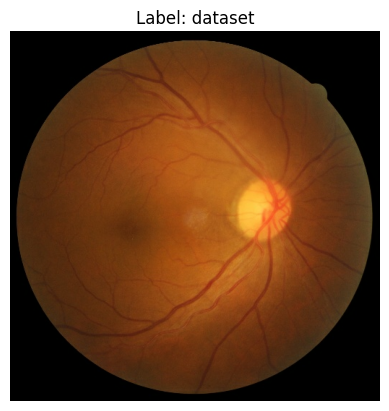

In [9]:

# Load the dataset
img_size = (512, 512)
batch_size = 32
seed = 42

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\Users\utkarsh\Downloads\retina",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=seed,
    validation_split=0.2, 
    subset="training"  
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\Users\utkarsh\Downloads\retina",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=seed,  
    validation_split=0.2, 
    subset="validation" 
)

# Show class names
print("Class names:", train_data.class_names)


def display_image(image, label):
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(f"Label: {train_data.class_names[label]}")
    plt.axis('off')
    plt.show()


image, label = next(iter(train_data))
display_image(image[11], label[11])

In [10]:
# Count the number of samples in each class
class_counts = {class_name: 0 for class_name in train_data.class_names}

for image, label in train_data:
    for l in label.numpy():
        class_counts[train_data.class_names[l]] += 1

class_counts

{'dataset': 3374}

In [11]:

def cnn_model(NUMBER_OF_CLASSES, input_shape=(256, 256, 3)):
    model = models.Sequential()

    # First Convolutional Block
    model.add(layers.Conv2D(16, (3, 3), strides=2, padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.MaxPooling2D((2, 2), strides=2))

    # Second Convolutional Block
    model.add(layers.Conv2D(32, (3, 3), strides=2, padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.MaxPooling2D((2, 2), strides=2))

    # Third Convolutional Block
    model.add(layers.Conv2D(64, (3, 3), strides=2, padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.MaxPooling2D((2, 2), strides=2))

    # Flatten and Dense Layers
    model.add(layers.Flatten())
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(NUMBER_OF_CLASSES, activation='softmax'))  # Softmax for multi-class classification

    # Compile the model
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',  # Suitable for integer labels
                  metrics=['acc'])

    return model


In [13]:

IMG_SIZE = (256, 256)  # Match this to your model

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    return image, label

train_data = train_data.map(preprocess)
val_data = val_data.map(preprocess)


In [14]:
#confusion matrix


y_pred = []
y_true = []

for x, y in val_data:
    y_pred.extend(cnn_model.predict(x).argmax(axis=1))
    y_true.extend(y.numpy())
    
cm = confusion_matrix(np.array(y_true), np.array(y_pred))


c:\Users\utkarsh\miniconda3\Lib\site-packages\keras\src\ops\nn.py:908: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/

c:\Users\utkarsh\miniconda3\Lib\site-packages\keras\src\ops\nn.py:908: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step


c:\Users\utkarsh\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [16]:
#plot confusion matrix


plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


NameError: name 'class_names' is not defined

<Figure size 1000x1000 with 0 Axes>

In [5]:
# save the model
cnn_model.save("F:\retinal disease\model.keras")

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
C:\Users\utkarsh\AppData\Local\Temp\ipykernel_6620\3883753510.py:2: SyntaxWarning: invalid escape sequence '\m'
  cnn_model.save("F:\retinal disease\model.keras")
C:\Users\utkarsh\AppData\Local\Temp\ipykernel_6620\3883753510.py:2: SyntaxWarning: invalid escape sequence '\m'
  cnn_model.save("F:\retinal disease\model.keras")


NameError: name 'cnn_model' is not defined

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


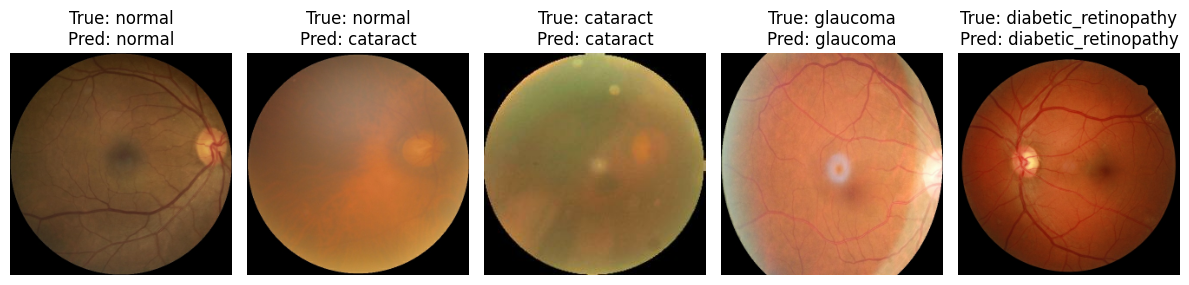

In [ ]:


image, label = next(iter(val_data))


predictions = cnn_model.predict(image)
predicted_labels = np.argmax(predictions, axis=1)
num_images = 5
fig, axes = plt.subplots(1, num_images, figsize=(12, 3))

for i in range(num_images):
    idx = random.randint(0, len(image) - 1)
    axes[i].imshow(image[idx].numpy().astype("uint8"))
    true_label = label[idx].numpy()
    predicted_label = predicted_labels[idx]
    axes[i].set_title(f"True: {train_data.class_names[true_label]}\nPred: {train_data.class_names[predicted_label]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()